In [58]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler


### Fetch and clean KDD data:

In [59]:
from sklearn.datasets import fetch_kddcup99

# Fetch data:
X_raw, y_raw = fetch_kddcup99(subset=None, return_X_y=True, as_frame=True)

In [60]:

# Since I only care about anomalous data, label all 'normal' data 0, and anything else 1.
y = (y_raw != b'normal.').astype(int)
print(y.unique())


[0 1]


In [61]:
# Make sure data is correct type
for col in X_raw.columns:
    if X_raw[col].dtype == 'object':
        converted = pd.to_numeric(X_raw[col], errors='coerce')
        
        if converted.notna().all():
            X_raw[col] = converted

In [62]:
# Convert categorical deatures to numeric:
numeric_cols = X_raw.select_dtypes(include=np.number).columns.tolist()

# We want to save X_raw for later use
X = X_raw.copy(deep=True)
le = LabelEncoder()
X['protocol_type'] = le.fit_transform(X['protocol_type'])
X['service'] = le.fit_transform(X['service'])
X['flag'] = le.fit_transform(X['flag'])
print(X)

scaler = MinMaxScaler()
scaler.fit(X[numeric_cols])

X[numeric_cols] = scaler.transform(X[numeric_cols])
# Add label column, 0 for normal, 1 of anomalie 
X['label'] = y

        duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0              0              1       22     9        181       5450     0   
1              0              1       22     9        239        486     0   
2              0              1       22     9        235       1337     0   
3              0              1       22     9        219       1337     0   
4              0              1       22     9        217       2032     0   
...          ...            ...      ...   ...        ...        ...   ...   
494016         0              1       22     9        310       1881     0   
494017         0              1       22     9        282       2286     0   
494018         0              1       22     9        203       1200     0   
494019         0              1       22     9        291       1200     0   
494020         0              1       22     9        219       1234     0   

        wrong_fragment  urgent  hot  ...  dst_host_count  dst_h

In [63]:
from sklearn.model_selection import train_test_split
## Split data into train, validation, test:

# 60% training, 40% temporary
train, temp = train_test_split(
    X,
    test_size=0.40,
    random_state=42
)

# Split remaining 40% into 20% validation and 20% test
validation, test = train_test_split(
    temp,
    test_size=0.50,
    random_state=42
)

print(f"Training:   {len(train)} ({len(train)/len(X):.0%})")
print(f"Validation: {len(validation)} ({len(validation)/len(X):.0%})")
print(f"Test:       {len(test)} ({len(test)/len(X):.0%})")

Training:   296412 (60%)
Validation: 98804 (20%)
Test:       98805 (20%)


In [64]:
# Extract formatted data to individual training, validation and test dataset for ease: 

y_train = train['label']
X_train = train.drop(columns=['label'])

y_validation = validation['label']
X_validation = validation.drop(columns=['label'])

y_test = test['label']
X_test = test.drop(columns=['label'])


'''
Because Isolation Forest is an unsupervised algorithm, I need to remove anomalies from the training data. 
Otherwise, the model may learn anomalous behaviour as part of the normal data distribution, reducing its
ability to identify anomalies in unseen data.

However, we want to keep anomalies in the dataset for the validation and test sets because these sets are 
used to evaluate the model's ability to correctly identify anomalous behaviour in unseen data.
'''
X_train_normal = X_train[y_train !=1] 

### Perform feature engineering to find most predictive features:

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

sel = SelectFromModel(RandomForestClassifier(n_estimators = 10, random_state=42))
sel.fit(X_train, y_train)
predictive_features = X_train.columns[(sel.get_support())]
print(predictive_features)
print(len(predictive_features))

Index(['service', 'flag', 'dst_bytes', 'logged_in', 'count', 'srv_count',
       'dst_host_count', 'dst_host_srv_diff_host_rate'],
      dtype='object')
8


### Train model and tune hyperparameters

In [66]:
# Now data is clean and features have been extracted, I can train the model, tune hyperparameters and train again:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# hyperparameter space:
contamination = [0.001, 0.01, 0.1, 0.5]
max_samples = [256, 512, 1024, 2048, 4096, 8192, 'auto']

'''
Note that `n_estimators` is kept fixed because increasing it does not significantly improve model performance. 
Instead, it primarily increases computational cost for a marginal performance gain. Accordingly, 500 estimators 
was selected as a reasonable balance between performance and computational efficiency.
'''

results = []

for c in contamination:
    for m in max_samples:
        isoForr = IsolationForest(
            n_estimators=500,
            contamination=c,
            max_samples=m,
            random_state=42,
            n_jobs=-1
        )
        # Train model:
        isoForr.fit(X_train_normal[predictive_features])
        # Infer on validation data:
        pred = isoForr.predict(X_validation[predictive_features])
        # Convert to standard format:
        pred = (pred == -1).astype(int)

        # Compute metrics
        accuracy = accuracy_score(y_validation, pred)
        precision = precision_score(y_validation, pred)
        recall = recall_score(y_validation, pred)
        f1 = f1_score(y_validation, pred)
        
        results.append({
            "max_samples": m,
            "contamination": c,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "accuracy",
    ascending=False
)
print(results_df.head(10))


   max_samples  contamination  accuracy  precision    recall        f1
12        8192           0.01  0.987521   0.997652  0.986763  0.992178
11        4096           0.01  0.986337   0.997662  0.985274  0.991429
10        2048           0.01  0.985557   0.997672  0.984289  0.990935
9         1024           0.01  0.982855   0.997549  0.981034  0.989222
8          512           0.01  0.979636   0.997809  0.976756  0.987170
18        4096           0.10  0.973867   0.975654  0.992176  0.983846
19        8192           0.10  0.973766   0.975603  0.992100  0.983783
17        2048           0.10  0.973544   0.975691  0.991722  0.983641
16        1024           0.10  0.973260   0.975399  0.991671  0.983468
15         512           0.10  0.972461   0.975115  0.990952  0.982970


# Put everything together, train and save final model from scratch

### Construct a pipeline that converts raw data, into predictions.

In [135]:
import numpy as np
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.ensemble import IsolationForest

# Most predictive categorical and numeric features:
categorical_cols = [
    'service',
    'flag'
]

numeric_cols = ['dst_bytes', 'logged_in', 'count', 'srv_count',
       'dst_host_count', 'dst_host_srv_diff_host_rate']

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_cols
        ),
        (
            "numeric",
            MinMaxScaler(),
            numeric_cols
        )
    ],
    remainder="passthrough"
)


pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("isolation_forest",
        IsolationForest(
            n_estimators=1000,
            contamination=0.01,
            max_samples=8192
        )
    )
])

#### Prepare final training data, different from above training data becuase its unprocessed (processing is done by pipeline)


In [139]:
X_raw_train = X_raw.iloc[:int(len(X_raw) * 0.6)]
X_raw_test =  X_raw.iloc[int(len(X_raw) * 0.6):]
y_raw_test = y.iloc[int(len(X_raw) * 0.6):]

# Remove outliers for training
normal_data = np.array(y[:int(len(y) * 0.6)])
X_raw_train_normal = X_raw_train[normal_data == 0]

inferencePipeline = pipeline.fit(X_raw_train_normal[predictive_features])

joblib.dump(inferencePipeline, 'inferencePipeline.pkl')

['inferencePipeline.pkl']

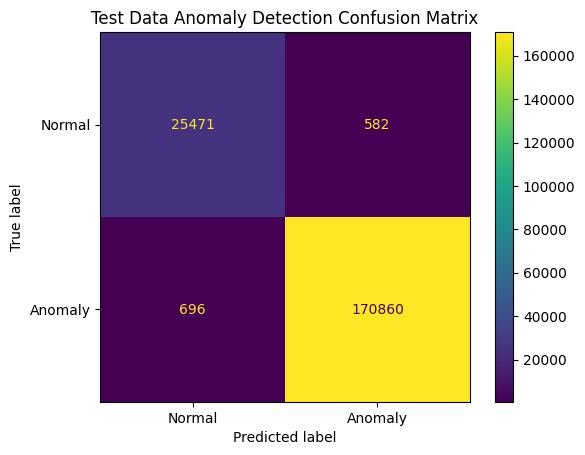

0.9935326832279906
0.9966052659208362
0.9959430156916692
0.9962740307523659


In [140]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


pred = inferencePipeline.predict(X_raw_test[predictive_features])
pred = (pred == -1).astype(int)


cm = confusion_matrix(y_raw_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot()
plt.title("Test Data Anomaly Detection Confusion Matrix")
plt.show()

accuracy = accuracy_score(y_raw_test, pred)
precision = precision_score(y_raw_test, pred)
recall = recall_score(y_raw_test, pred)
f1 = f1_score(y_raw_test, pred)

print(accuracy)
print(precision)
print(recall)
print(f1)

